In [1]:
import sys
sys.path.append("../")  # Goes up to "project/"
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_binary_conf(NX,NT,path):
    """
    Function used for opening a gauge configuration in binary format.
    It can also be used to open a .tv file with a test vector, necessary
    for training.
    """
    N = 2*NX*NT
    x, t, mu, vals = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N,dtype=complex)
    #U[μ,t,x]
    #conf = np.zeros((2,var.NT,var.NX),dtype=complex)
    data = np.fromfile(path, dtype=[('x', 'i4'),
                ('t', 'i4'),
                ('mu', 'i4'),
                ('re','f8'),
                ('im','f8')])
    conf = np.zeros((2, NT, NX), dtype=np.complex128)
    conf[data['mu'], data['t'], data['x']] = data['re'] + 1j * data['im']            
    return conf

In [3]:
#Open test vectors of a particular gauge configuration and store them in columns
beta, N, m0_str = 2, 64, "-01884"
nconf = 0
tv = 0 
NV = 30
spin = 0 #0 or 1
test_vectors = np.zeros((NV,N*N),dtype=complex)
for tv in range(NV):
    path = "../real_tv/b{0}_{1}x{1}/m-018/tvector_{1}x{1}_b{0}0000_m{2}_nconf{3}_tv{4}.tv".format(
        beta, N, m0_str, nconf, tv
        )
    test_vector = read_binary_conf(N,N,path)
    flatten_vector_spin0 = test_vector[spin].flatten()
    test_vectors[tv] = flatten_vector_spin0

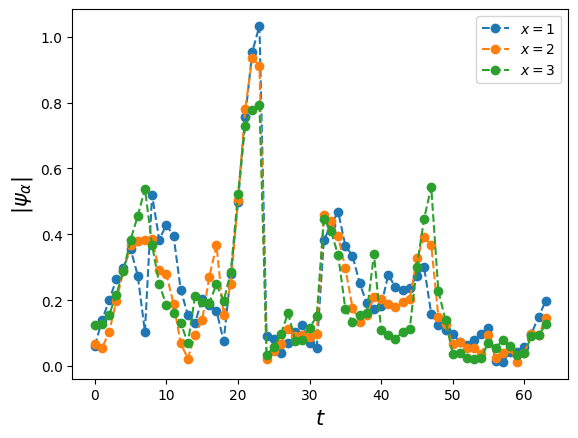

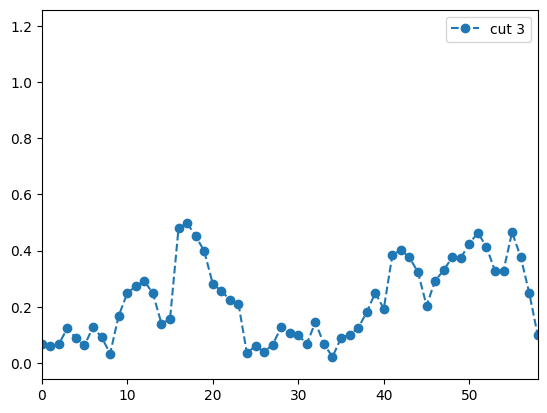

In [4]:
#We plot the test vectors by taking cuts at different x
X = np.arange(0,N,1)
for i in range(1,4):
    cut1 = np.abs(test_vector[spin,:,i])
    plt.plot(X,cut1,marker='o',linestyle='--',label=r'$x=${0}'.format(i))
plt.xlabel(r"$t$",size=15)
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.legend()
plt.show()
tvec = np.abs(test_vector[spin].reshape(-1))
#Linearize everything
X = np.arange(0,tvec.shape[0])
plt.plot(X,tvec,marker='o',linestyle='--',label='cut {0}'.format(i))
plt.legend()
plt.xlim([0,58])
plt.show()

# SVD 1
* Restrict test vectors to a lattice block and apply SVD

In [5]:
def decomposed_vectors(blockID,block_x,block_t,spin,test_vectors):
    """
    Restrict test vectors to a lattice block
    """
    Nv, lalala, Nt, Nx = test_vectors.shape
    Nblocks =  block_x*block_t

    x_elements = Nx // block_x
    t_elements = Nt // block_t

    assert blockID < Nblocks, "blockID should be within the range of the number of lattice blocks"
    #v = np.zeros((dim,Nv*Nblocks),dtype=complex)
    
    bx = blockID // block_x
    bt = blockID % block_t 
    #----Coordinates of elements inside block----#
    xini, tini = x_elements * bx, t_elements * bt
    xfin = xini + x_elements
    tfin = tini + t_elements
    #--------------------------------------------#
    return test_vectors[:, spin, tini:tfin, xini:xfin]  #[tv,s,t,x]

In [6]:
#Restrict test vectors to a particular block and apply SVD
Nx, Nt, block_x, block_t = 64,64,8,8
x_elements, t_elements = Nx//block_x, Nt//block_t
print("x elements",x_elements)
print("t elements",t_elements)
spin = 0
blockID = 0

beta, m0_str = 2, "-01884"
nconf = 0
NV = 30
test_vectors = np.zeros((NV,2,Nx,Nt),dtype=complex)
for tv in range(NV):
    path = "../real_tv/b{0}_{1}x{1}/m-018/tvector_{1}x{1}_b{0}0000_m{2}_nconf{3}_tv{4}.tv".format(
        beta, N, m0_str, nconf, tv
        )
    test_vector = read_binary_conf(N,N,path)
    #flatten_vector_spin0 = test_vector[0].flatten()
    test_vectors[tv] = test_vector

dtv = decomposed_vectors(blockID,block_x,block_t,spin,test_vectors) #[]
dtv =  np.transpose(dtv.reshape(NV,-1))
print(dtv.shape)

x elements 8
t elements 8
(64, 30)


In [7]:
U, s, Vh = np.linalg.svd(dtv, full_matrices=False, compute_uv=True, hermitian=False)

if np.allclose(np.matmul(np.matmul(U,np.diag(s)),Vh),dtv):
    print("matrix succesfully reconstructed")
else:
    print("something wrong with the SVD")
print("U shape",U.shape)
print("s shape",s.shape)
print("Vh shape",Vh.shape)
k = 10
assert k<NV, "k has to be smaller than NV"
Uk, sk, Vk = U[:,:k], s[:k], Vh[:k,:]
print("-------------------")
print("Uk shape",Uk.shape)
print("sk shape",sk.shape)
print("Vk shape",Vk.shape)
low_rank_tv = np.matmul(np.matmul(Uk,np.diag(sk)),Vk)
print("Test vectors shape",low_rank_tv.shape)

matrix succesfully reconstructed
U shape (64, 30)
s shape (30,)
Vh shape (30, 30)
-------------------
Uk shape (64, 10)
sk shape (10,)
Vk shape (10, 30)
Test vectors shape (64, 30)


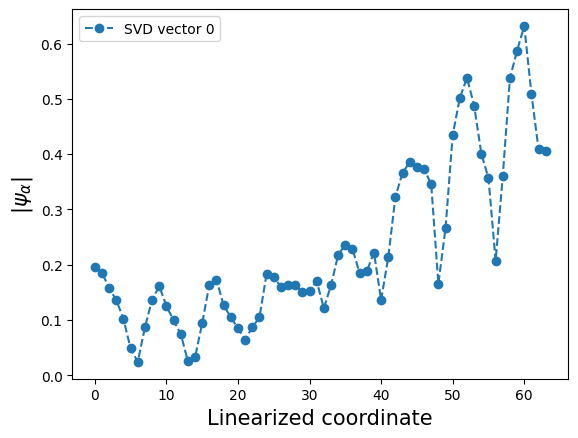

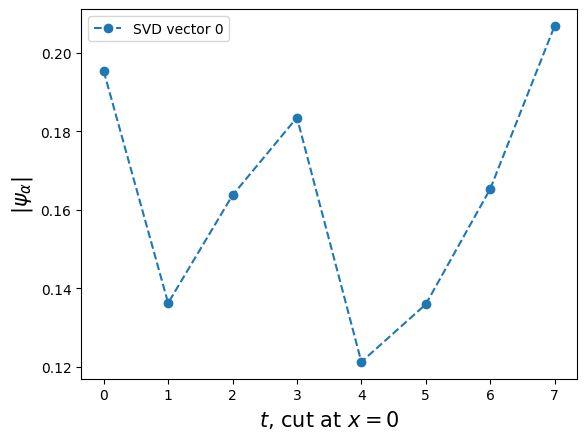

In [8]:
tv = 0
X = np.arange(0,low_rank_tv.shape[0])
plt.plot(X,np.abs(low_rank_tv[:,tv]),marker='o',linestyle='--',label='SVD vector {0}'.format(tv))
plt.legend()
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.xlabel("Linearized coordinate",size=15)
plt.show()

psi = low_rank_tv.reshape(t_elements,x_elements,NV)
X = np.arange(0,psi.shape[0])
cut = 0
plt.plot(X,np.abs(psi[:,cut,tv]),marker='o',linestyle='--',label='SVD vector {0}'.format(tv))
plt.legend()
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.xlabel(r"$t$, cut at $x=${0}".format(cut),size=15)
plt.show()

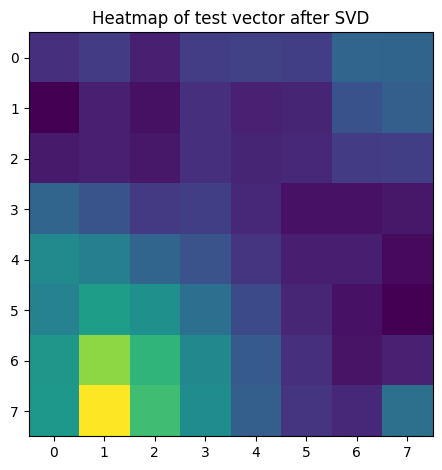

In [9]:
fig, ax = plt.subplots()
im = ax.imshow(np.abs(psi[:,:,10]))

ax.set_xticks(range(t_elements))
ax.set_yticks(range(x_elements))

ax.set_title("Heatmap of test vector after SVD")
fig.tight_layout()
plt.show()


# SVD 2
* Restrict test vectors and apply SVD, but this time we keep the original dimensions of the vectors and only zero-out those components outside of the domain.

In [10]:
def decomposed_vectors_v2(blockID,block_x,block_t,spin,test_vectors):
    """
    Restrict test vectors over a lattice block
    """
    Nv, lalala, Nt, Nx = test_vectors.shape
    Nblocks =  block_x*block_t

    x_elements = Nx // block_x
    t_elements = Nt // block_t

    assert blockID < Nblocks, "blockID should be within the range of the number of lattice blocks"
    #v = np.zeros((dim,Nv*Nblocks),dtype=complex)
    
    bx = blockID // block_x
    bt = blockID % block_t 
    #----Coordinates of elements inside block----#
    xini, tini = x_elements * bx, t_elements * bt
    xfin = xini + x_elements
    tfin = tini + t_elements
    #--------------------------------------------#
    tvec = np.zeros((Nv,Nt,Nx),dtype=complex)
    for x in range(Nx):
        for t in range(Nt):
            if xini<=x<=xfin and tini<=t<=tfin:
                tvec[:,t,x] = test_vectors[:,spin,t,x]
    
    return tvec 

In [11]:
#Restrict test vectors to a particular block and apply SVD
Nx, Nt, block_x, block_t = 64,64,8,8
x_elements, t_elements = Nx//block_x, Nt//block_t
spin = 0
blockID = 0

beta, m0_str = 2, "-01884"
nconf = 0
NV = 30
test_vectors = np.zeros((NV,2,Nx,Nt),dtype=complex)
for tv in range(NV):
    path = "../real_tv/b{0}_{1}x{1}/m-018/tvector_{1}x{1}_b{0}0000_m{2}_nconf{3}_tv{4}.tv".format(
        beta, N, m0_str, nconf, tv
        )
    test_vector = read_binary_conf(N,N,path)
    #flatten_vector_spin0 = test_vector[0].flatten()
    test_vectors[tv] = test_vector

blockID = 0
dtv2 = decomposed_vectors_v2(blockID,block_x,block_t,spin,test_vectors) #[]
dtv2 =  np.transpose(dtv2.reshape(NV,-1))
print("matrix shape",dtv2.shape)

U, s, Vh = np.linalg.svd(dtv2, full_matrices=False, compute_uv=True, hermitian=False)

if np.allclose(np.matmul(np.matmul(U,np.diag(s)),Vh),dtv2):
    print("matrix succesfully reconstructed")
else:
    print("something wront with the SVD")
print("U shape",U.shape)
print("s shape",s.shape)
print("Vh shape",Vh.shape)
k = 10
assert k<NV, "k has to be smaller than NV"
Uk, sk, Vk = U[:,:k], s[:k], Vh[:k,:]
print("-------------------")
print("Uk shape",Uk.shape)
print("sk shape",sk.shape)
print("Vk shape",Vk.shape)
low_rank_tv = np.matmul(np.matmul(Uk,np.diag(sk)),Vk)
print("Test vectors shape",low_rank_tv.shape)

matrix shape (4096, 30)
matrix succesfully reconstructed
U shape (4096, 30)
s shape (30,)
Vh shape (30, 30)
-------------------
Uk shape (4096, 10)
sk shape (10,)
Vk shape (10, 30)
Test vectors shape (4096, 30)


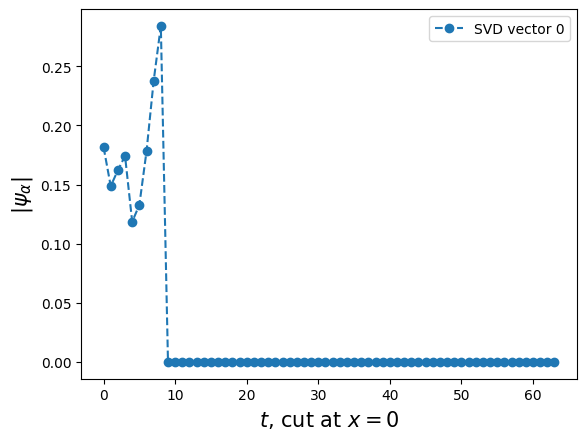

In [12]:
tv = 0
psi = low_rank_tv.reshape(Nt,Nx,NV)
X = np.arange(0,psi.shape[0])
cut = 0
plt.plot(X,np.abs(psi[:,cut,tv]),marker='o',linestyle='--',label='SVD vector {0}'.format(tv))
plt.legend()
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.xlabel(r"$t$, cut at $x=${0}".format(cut),size=15)
plt.show()

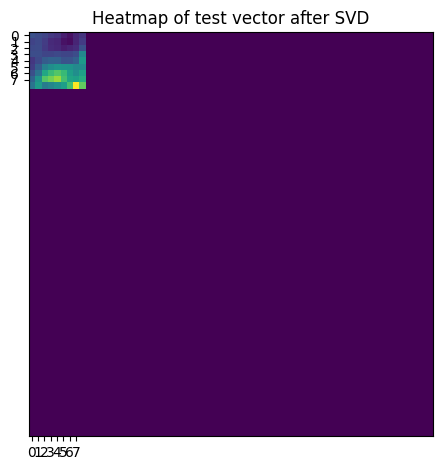

In [13]:
fig, ax = plt.subplots()
im = ax.imshow(np.abs(psi[:,:,0]))

ax.set_xticks(range(8))
ax.set_yticks(range(8))

ax.set_title("Heatmap of test vector after SVD")
fig.tight_layout()
plt.show()

In [14]:
#Restrict test vectors to subdomain and apply SVD or
#Apply SVD to test vectors and then restrict result to subdomain?

# SVD 3

* Now we apply the SVD to the matrix with test vectors and then restrict the result to a domain.

In [15]:
def restrict_vector(blockID,block_x,block_t,Nx,Nt,low_rank_tv):
    """
    Restrict test vectors over a lattice block
    """
    test_vec_reshape = low_rank_tv.reshape(Nt,Nx)
    Nblocks =  block_x*block_t
    
    x_elements = Nx // block_x
    t_elements = Nt // block_t

    assert blockID < Nblocks, "blockID should be within the range of the number of lattice blocks"
    #v = np.zeros((dim,Nv*Nblocks),dtype=complex)
    
    bx = blockID // block_x
    bt = blockID % block_t 
    #----Coordinates of elements inside block----#
    xini, tini = x_elements * bx, t_elements * bt
    xfin = xini + x_elements
    tfin = tini + t_elements
    #--------------------------------------------#
    tvec = np.zeros((Nt,Nx),dtype=complex)
    for x in range(Nx):
        for t in range(Nt):
            if xini<=x<=xfin and tini<=t<=tfin:
                tvec[t,x] = test_vec_reshape[t,x]
    
    return tvec 

In [16]:
#Restrict test vectors to a particula block and apply SVD
Nx, Nt, block_x, block_t = 64,64,8,8
x_elements, t_elements = Nx//block_x, Nt//block_t
spin = 0
blockID = 0

beta, m0_str = 2, "-01884"
nconf = 0
NV = 30
test_vectors = np.zeros((NV,2,Nx,Nt),dtype=complex)
for tv in range(NV):
    path = "../real_tv/b{0}_{1}x{1}/m-018/tvector_{1}x{1}_b{0}0000_m{2}_nconf{3}_tv{4}.tv".format(
        beta, N, m0_str, nconf, tv
        )
    test_vector = read_binary_conf(N,N,path)
    #flatten_vector_spin0 = test_vector[0].flatten()
    test_vectors[tv] = test_vector

#dtv = decomposed_vectors(blockID,block_x,block_t,spin,test_vectors) #[]
dtv =  np.transpose(test_vectors[:,spin,:,:].reshape(NV,-1))
#print(dtv.shape)

In [17]:
U, s, Vh = np.linalg.svd(dtv, full_matrices=False, compute_uv=True, hermitian=False)

if np.allclose(np.matmul(np.matmul(U,np.diag(s)),Vh),dtv):
    print("matrix succesfully reconstructed")
else:
    print("something wrong with the SVD")
print("U shape",U.shape)
print("s shape",s.shape)
print("Vh shape",Vh.shape)
k = 10
assert k<NV, "k has to be smaller than NV"
Uk, sk, Vk = U[:,:k], s[:k], Vh[:k,:]
print("-------------------")
print("Uk shape",Uk.shape)
print("sk shape",sk.shape)
print("Vk shape",Vk.shape)
low_rank_tv = np.matmul(np.matmul(Uk,np.diag(sk)),Vk)
print("Test vectors shape",low_rank_tv.shape)

matrix succesfully reconstructed
U shape (4096, 30)
s shape (30,)
Vh shape (30, 30)
-------------------
Uk shape (4096, 10)
sk shape (10,)
Vk shape (10, 30)
Test vectors shape (4096, 30)


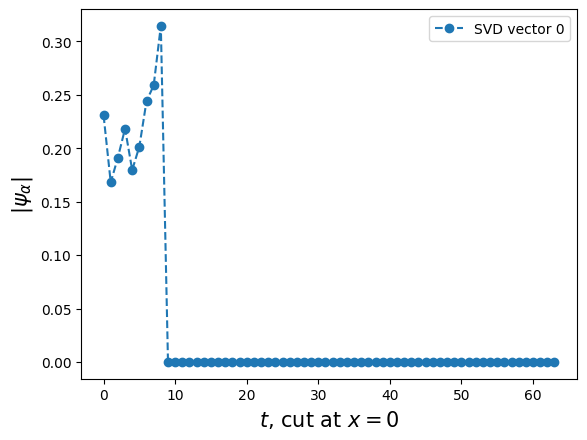

In [18]:
tvID = 0
tvec = low_rank_tv[:,tvID].reshape(Nt,Nx)
tvec = restrict_vector(blockID,block_x,block_t,Nx,Nt,tvec)
X = np.arange(0,tvec.shape[0])
cut = 0
plt.plot(X,np.abs(tvec[:,cut]),marker='o',linestyle='--',label='SVD vector {0}'.format(tvID))
plt.legend()
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.xlabel(r"$t$, cut at $x=${0}".format(cut),size=15)
plt.show()